<a href="https://colab.research.google.com/github/javi2621/taller-de-econometria/blob/main/ej.taller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages(c("wooldridge", "corrplot"))
library(wooldridge)
library(corrplot)

# Cargamos la base de datos y le ponemos un nombre fácil
data("lawsch85")
datos <- lawsch85

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



In [2]:
summary(datos)

      rank            salary           cost            LSAT      
 Min.   :  1.00   Min.   :24900   Min.   : 2623   Min.   :140.0  
 1st Qu.: 40.75   1st Qu.:29950   1st Qu.: 9664   1st Qu.:155.0  
 Median : 83.50   Median :34725   Median :12898   Median :158.0  
 Mean   : 83.75   Mean   :38947   Mean   :12736   Mean   :158.3  
 3rd Qu.:125.50   3rd Qu.:41350   3rd Qu.:16129   3rd Qu.:161.0  
 Max.   :175.00   Max.   :78325   Max.   :20518   Max.   :171.0  
                  NA's   :8       NA's   :6       NA's   :6      
      GPA            libvol          faculty            age        
 Min.   :2.730   Min.   : 124.0   Min.   : 17.00   Min.   :  3.00  
 1st Qu.:3.200   1st Qu.: 235.0   1st Qu.: 45.00   1st Qu.: 63.50  
 Median :3.300   Median : 302.0   Median : 58.00   Median : 85.00  
 Mean   :3.303   Mean   : 347.1   Mean   : 70.73   Mean   : 85.82  
 3rd Qu.:3.410   3rd Qu.: 400.0   3rd Qu.: 86.25   3rd Qu.:112.50  
 Max.   :3.820   Max.   :1745.0   Max.   :245.00   Max.   :206.0

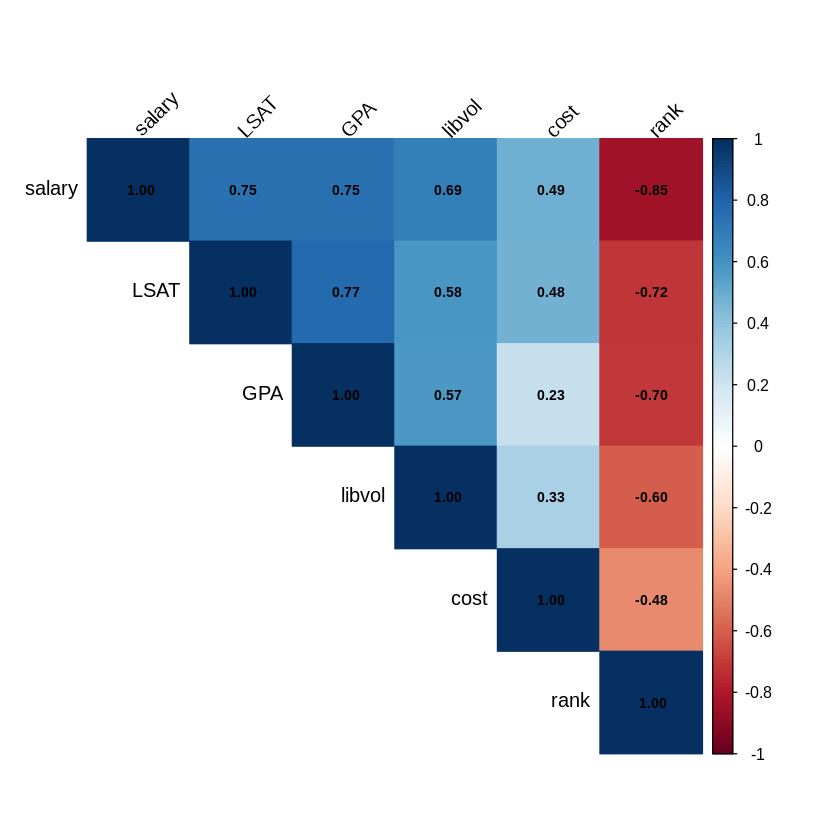

In [3]:
datos_limpios <- na.omit(datos[, c("salary", "LSAT", "GPA", "libvol", "cost", "rank")])

matriz <- cor(datos_limpios)
corrplot(matriz, method="color", type="upper", addCoef.col="black", tl.col="black", tl.srt=45, number.cex=0.7)

In [4]:
mod_simple <- lm(log(salary) ~ LSAT, data = datos_limpios)
summary(mod_simple)


Call:
lm(formula = log(salary) ~ LSAT, data = datos_limpios)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.40090 -0.11588  0.00068  0.11802  0.48707 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 3.357041   0.544299   6.168 7.65e-09 ***
LSAT        0.045326   0.003432  13.205  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1834 on 134 degrees of freedom
Multiple R-squared:  0.5655,	Adjusted R-squared:  0.5622 
F-statistic: 174.4 on 1 and 134 DF,  p-value: < 2.2e-16


In [5]:
mod_multi <- lm(log(salary) ~ LSAT + GPA + log(libvol) + log(cost) + rank, data = datos_limpios)
summary(mod_multi)


Call:
lm(formula = log(salary) ~ LSAT + GPA + log(libvol) + log(cost) + 
    rank, data = datos_limpios)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.301356 -0.084982 -0.004359  0.077935  0.288614 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  8.3432262  0.5325192  15.667  < 2e-16 ***
LSAT         0.0046965  0.0040105   1.171  0.24372    
GPA          0.2475238  0.0900371   2.749  0.00683 ** 
log(libvol)  0.0949932  0.0332544   2.857  0.00499 ** 
log(cost)    0.0375539  0.0321061   1.170  0.24427    
rank        -0.0033246  0.0003485  -9.541  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1124 on 130 degrees of freedom
Multiple R-squared:  0.8417,	Adjusted R-squared:  0.8356 
F-statistic: 138.2 on 5 and 130 DF,  p-value: < 2.2e-16


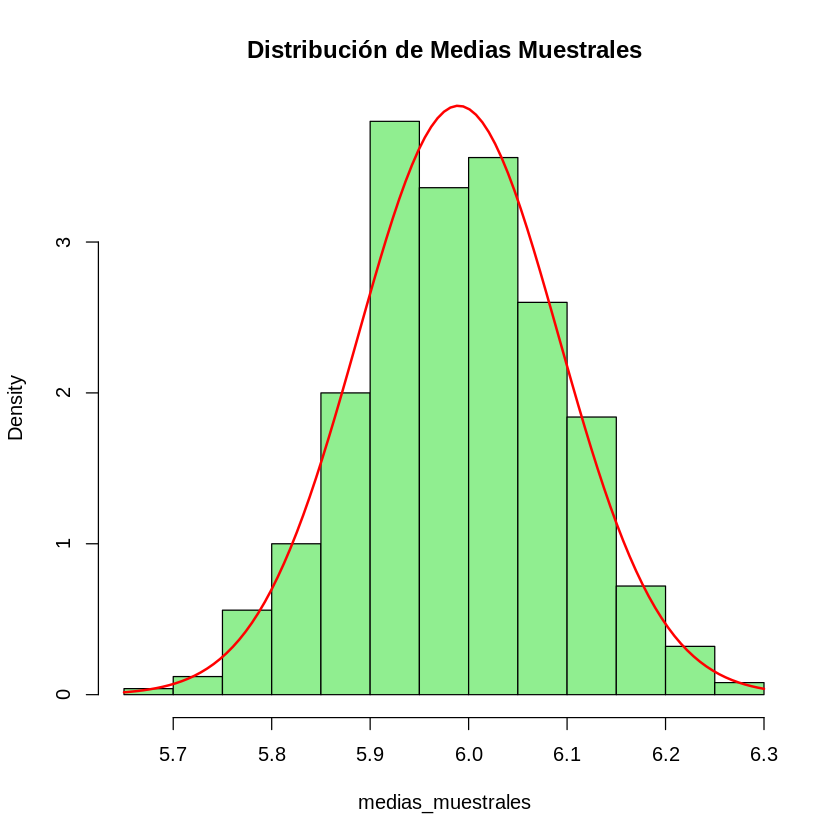

In [6]:
set.seed(123)

poblacion <- runif(100000, min=2, max=10)
R <- 500
m <- 500
medias_muestrales <- numeric(R)

for(i in 1:R) {
  muestra <- sample(poblacion, size=m, replace=TRUE)
  medias_muestrales[i] <- mean(muestra)
}

hist(medias_muestrales, probability=TRUE, main="Distribución de Medias Muestrales", col="lightgreen")
curve(dnorm(x, mean=mean(medias_muestrales), sd=sd(medias_muestrales)), add=TRUE, col="red", lwd=2)